# CIE 457 — Statistical Inference and Data Analysis
## MLE Estimation and Estimator Distribution in Linear Regression

---

**University of Science and Technology · Zewail City** &emsp; Spring 2026

|  | |
|---|---|
| **Authors** | Ibrahim Hanafy · 202200518 &ensp;·&ensp; Mai Ibrahim · 202200504 &ensp;·&ensp; Mohamed Alaa · 202100905 |
| **Instructor** | Dr. Mahmoud Abdelaziz |
| **Teaching Assistants** | Eng. Nasrah Mohamed &ensp;·&ensp; Eng. Aya Abdelaziz |

*This notebook develops a rigorous treatment of MLE in linear regression, covering estimator distributions, Monte Carlo simulation, and real data analysis under both homoscedastic and heteroscedastic noise.*

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Imports loaded ✓")

Imports loaded ✓


In [30]:
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.grid'         : True,
    'grid.color'        : '#e0e0e0',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.8,
    'lines.linewidth'   : 1.8,
    'font.family'       : 'serif',
})
COLORS = {
    'ols'    : '#2196F3',
    'wls'    : '#E53935',
    'theory' : '#43A047',
    'data'   : '#6D4C41',
    'accent' : '#FB8C00',
}
print("Styling loaded ✓")

Styling loaded ✓


---

## Theory — MLE and Model Formulation

*Likelihood functions · Estimator derivation · Randomness of $\hat{\boldsymbol{\beta}}$*

### 1. Homoscedastic Gaussian Likelihood

**Model:**

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I})$$

Each observation independently: $y_i \mid \mathbf{x}_i, \boldsymbol{\beta} \sim \mathcal{N}(\mathbf{x}_i^\top\boldsymbol{\beta},\, \sigma^2)$.

**Likelihood:**

$$\mathcal{L}(\boldsymbol{\beta}, \sigma^2 \mid \mathbf{y}, \mathbf{X}) = \prod_{i=1}^{n}(2\pi\sigma^2)^{-1/2}\exp\!\left(-\frac{(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2}{2\sigma^2}\right)$$

**Log-likelihood:**

$$\ell(\boldsymbol{\beta}, \sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\left\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\right\|^2$$

**MLE derivation:** Maximising $\ell$ over $\boldsymbol{\beta}$ is equivalent to minimising the OLS objective $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$:

$$\frac{\partial\ell}{\partial\boldsymbol{\beta}} = \frac{1}{\sigma^2}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = \mathbf{0} \;\Longrightarrow\; \mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}$$

$$\boxed{\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

For $\sigma^2$: solving $\partial\ell/\partial\sigma^2 = 0$ gives $\hat{\sigma}^2 = \|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2/n$.

**Distribution of $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}$:**

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} \sim \mathcal{N}\!\left(\boldsymbol{\beta},\;\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}\right)$$

### 2. Heteroscedastic Gaussian Likelihood

**Model:**

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\,\boldsymbol{\Sigma}), \qquad \boldsymbol{\Sigma} = \operatorname{diag}(\sigma_1^2,\ldots,\sigma_n^2) \neq \sigma^2\mathbf{I}$$

**Likelihood:**

$$\mathcal{L}(\boldsymbol{\beta} \mid \mathbf{y}, \mathbf{X}) = (2\pi)^{-n/2}|\boldsymbol{\Sigma}|^{-1/2}\exp\!\left(-\tfrac{1}{2}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})\right)$$

**Log-likelihood:**

$$\ell(\boldsymbol{\beta}) = \mathrm{const} - \frac{1}{2}\sum_{i=1}^{n}\frac{(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2}{\sigma_i^2}$$

**MLE — WLS:** Maximising $\ell$ is equivalent to minimising the weighted residual sum $Q(\boldsymbol{\beta}) = \sum_i w_i(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2$ with $w_i = 1/\sigma_i^2$:

$$\frac{\partial Q}{\partial\boldsymbol{\beta}} = \mathbf{0} \;\Longrightarrow\; \mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{y}$$

$$\boxed{\hat{\boldsymbol{\beta}}_{\mathrm{WLS}} = (\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{y}}$$

**Distributions:**

- $\hat{\boldsymbol{\beta}}_{\mathrm{WLS}} \sim \mathcal{N}\!\left(\boldsymbol{\beta},\;(\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{X})^{-1}\right)$ — efficient MLE
- $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}$ remains unbiased, but with sandwich covariance (larger than CRLB):

$$\operatorname{Var}(\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}) = (\mathbf{X}^\top\mathbf{X})^{-1}\,\mathbf{X}^\top\boldsymbol{\Sigma}\,\mathbf{X}\,(\mathbf{X}^\top\mathbf{X})^{-1}$$

### 3. The Estimator as a Random Variable

Substituting $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ into the OLS formula:

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}) = \boldsymbol{\beta} + (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\varepsilon}$$

**Key insight:** $\mathbf{X}$ is fixed (deterministic design matrix); $\boldsymbol{\varepsilon}$ is the only source of randomness. Since $\hat{\boldsymbol{\beta}}$ is a linear function of the Gaussian $\boldsymbol{\varepsilon}$, it is itself exactly Gaussian:

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} \sim \mathcal{N}\!\left(\boldsymbol{\beta},\;\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}\right)$$

Every new dataset draws a new $\boldsymbol{\varepsilon} \to$ a new $\hat{\boldsymbol{\beta}}$. Confidence intervals and hypothesis tests exploit this known distribution. The Monte Carlo simulations in Parts 1–2 make this concrete by empirically constructing the distribution across $M$ repeated experiments and comparing it to the theoretical Gaussian.

---

## Part 1 — Linear Regression under Homoscedastic Noise

*Monte Carlo simulation of the OLS estimator distribution*

We consider $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ with $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$. The MLE is OLS:

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y} \;\sim\; \mathcal{N}\!\left(\boldsymbol{\beta},\;\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}\right)$$

The Monte Carlo simulation below empirically verifies this result by repeatedly sampling from the true DGP and collecting estimates.

| Parameter | Value |
|---|---|
| $n$ (observations) | 100 |
| $p$ (features) | 3 |
| $\boldsymbol{\beta}$ (true) | $[1,\,2,\,3]$ |
| $\sigma^2$ (noise variance) | $1.0$ |
| $M$ (trials) | 5000 |
| Noise model | $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$ — Homoscedastic |

In [31]:
n      = 100
p      = 3
beta   = np.array([1.0, 2.0, 3.0])
sigma2 = 1.0
M      = 5000

np.random.seed(42)
X = np.random.randn(n, p)

XtX_inv       = np.linalg.inv(X.T @ X)
theo_cov_homo = sigma2 * XtX_inv

print("Design matrix X shape :", X.shape)
print("True β                 :", beta)
print("σ²                     :", sigma2)
print("Theoretical cov diag   :", np.diag(theo_cov_homo).round(6))

Design matrix X shape : (100, 3)
True β                 : [1. 2. 3.]
σ²                     : 1.0
Theoretical cov diag   : [0.014958 0.010437 0.008393]


### 1.1 — OLS Implementation

The OLS estimator is the MLE under homoscedastic Gaussian noise:

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Implemented directly using NumPy — no black-box solvers. Since $\mathbf{X}$ is fixed across all trials, $(\mathbf{X}^\top\mathbf{X})^{-1}$ is precomputed once for efficiency.

In [32]:
def ols(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

eps_test  = np.random.normal(0, np.sqrt(sigma2), n)
y_test    = X @ beta + eps_test
beta_test = ols(X, y_test)
print("Single OLS estimate:", beta_test.round(4))
print("True β             :", beta)

Single OLS estimate: [0.9368 1.9307 2.8982]
True β             : [1. 2. 3.]


### 1.2 — Monte Carlo Simulation

For each trial $m = 1, \ldots, M$:

1. Draw $\boldsymbol{\varepsilon}^{(m)} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$
2. Generate $\mathbf{y}^{(m)} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}^{(m)}$
3. Compute $\hat{\boldsymbol{\beta}}^{(m)} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}^{(m)}$

After $M$ trials, we collect $\{\hat{\boldsymbol{\beta}}^{(1)}, \ldots, \hat{\boldsymbol{\beta}}^{(M)}\}$ and compute empirical mean and covariance to compare against theory.

In [33]:
beta_hats_homo = np.zeros((M, p))
for m in range(M):
    eps               = np.random.normal(0, np.sqrt(sigma2), n)
    y                 = X @ beta + eps
    beta_hats_homo[m] = ols(X, y)

print(f"Monte Carlo complete — {M} trials ✓")
print(f"beta_hats shape: {beta_hats_homo.shape}")

Monte Carlo complete — 5000 trials ✓
beta_hats shape: (5000, 3)


### 1.3 — Empirical vs Theoretical: Mean & Covariance

**Expected results:**
- Empirical mean $\to \boldsymbol{\beta}$ (OLS is unbiased)
- Empirical covariance $\to \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$ (theoretical prediction)

In [34]:
emp_mean = beta_hats_homo.mean(axis=0)
emp_cov  = np.cov(beta_hats_homo.T)

print("=" * 52)
print(f"{'':>20} {'Empirical':>12} {'Theoretical':>12}")
print("=" * 52)
for i in range(p):
    print(f"  E[β̂_{i+1}]          {emp_mean[i]:>12.6f} {beta[i]:>12.6f}")
print("-" * 52)
print("\nEmpirical Covariance:\n",  emp_cov.round(6))
print("\nTheoretical Covariance:\n", theo_cov_homo.round(6))

                        Empirical  Theoretical
  E[β̂_1]              1.000673     1.000000
  E[β̂_2]              2.001188     2.000000
  E[β̂_3]              2.999210     3.000000
----------------------------------------------------

Empirical Covariance:
 [[0.014874 0.001133 0.001191]
 [0.001133 0.010561 0.001191]
 [0.001191 0.001191 0.008583]]

Theoretical Covariance:
 [[0.014958 0.001054 0.001375]
 [0.001054 0.010437 0.001335]
 [0.001375 0.001335 0.008393]]


### 1.4 — Estimator Distribution: Histogram & KDE vs Theory

The empirical distribution of each $\hat{\beta}_j$ component is compared against the theoretical Gaussian $\mathcal{N}(\beta_j,\, \sigma^2[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj})$.

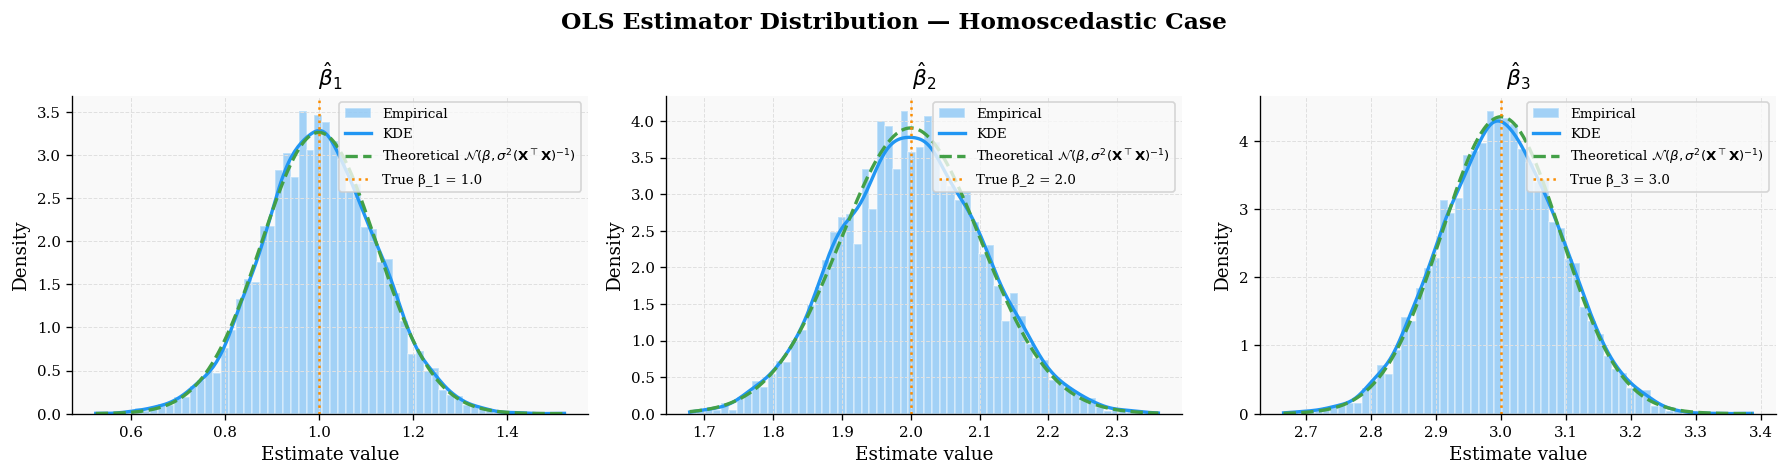

In [35]:
fig, axes = plt.subplots(1, p, figsize=(15, 4))
fig.suptitle("OLS Estimator Distribution — Homoscedastic Case",
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    samples  = beta_hats_homo[:, i]
    theo_std = np.sqrt(theo_cov_homo[i, i])
    x_range  = np.linspace(samples.min(), samples.max(), 300)
    theo_pdf = stats.norm.pdf(x_range, loc=beta[i], scale=theo_std)

    ax.hist(samples, bins=60, density=True, alpha=0.4,
            color=COLORS['ols'], edgecolor='white', label='Empirical')
    kde = stats.gaussian_kde(samples)
    ax.plot(x_range, kde(x_range), color=COLORS['ols'], lw=2, label='KDE')
    ax.plot(x_range, theo_pdf, color=COLORS['theory'],
            lw=2, linestyle='--', label=r'Theoretical $\mathcal{N}(\beta, \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1})$')
    ax.axvline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle=':', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"$\\hat{{\\beta}}_{i+1}$")
    ax.set_xlabel("Estimate value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/homo_distribution.png", bbox_inches='tight')
plt.show()

---

## Part 2 — Linear Regression under Heteroscedastic Noise

*OLS vs WLS — efficiency comparison via Monte Carlo simulation*

We now consider $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$ with $\boldsymbol{\Sigma} \neq \sigma^2\mathbf{I}$. Specifically:

$$\sigma_i^2 = 0.5 + 2\cdot(x_{i1} - \min x_1)^2$$

so variance grows with the first feature. Two estimators are compared:

- **OLS** — ignores the noise structure; unbiased but inefficient: $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} \sim \mathcal{N}\!\left(\boldsymbol{\beta},\;(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\Sigma}\mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\right)$
- **WLS** — the true MLE; accounts for $\boldsymbol{\Sigma}$ and is efficient: $\hat{\boldsymbol{\beta}}_{\mathrm{WLS}} \sim \mathcal{N}\!\left(\boldsymbol{\beta},\;(\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{X})^{-1}\right)$

| Parameter | Value |
|---|---|
| $n$ | 100 |
| $p$ | 3 |
| $\boldsymbol{\beta}$ | $[1,2,3]$ |
| $M$ | 5000 |
| $\boldsymbol{\Sigma}$ structure | $\operatorname{diag}(\sigma_i^2)$, $\;\sigma_i^2 = 0.5 + 2(x_{i1} - \min x_1)^2$ |

In [36]:
sigma2_i  = 0.5 + 2.0 * (X[:, 0] - X[:, 0].min())**2
Sigma     = np.diag(sigma2_i)
Sigma_inv = np.diag(1.0 / sigma2_i)

A              = np.linalg.inv(X.T @ X)
theo_cov_ols_h = A @ X.T @ Sigma @ X @ A
theo_cov_wls   = np.linalg.inv(X.T @ Sigma_inv @ X)

print(f"σᵢ² range : [{sigma2_i.min():.4f}, {sigma2_i.max():.4f}]")
print("\nTheoretical OLS cov diag:", np.diag(theo_cov_ols_h).round(6))
print("Theoretical WLS cov diag:", np.diag(theo_cov_wls).round(6))

σᵢ² range : [0.5000, 34.0550]

Theoretical OLS cov diag: [0.227112 0.105327 0.097262]
Theoretical WLS cov diag: [0.04933  0.069433 0.056183]


### 2.1 — WLS Implementation

The WLS estimator is the MLE under heteroscedastic Gaussian noise:

$$\hat{\boldsymbol{\beta}}_{\mathrm{WLS}} = (\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{X})^{-1}\mathbf{X}^\top\boldsymbol{\Sigma}^{-1}\mathbf{y}$$

For diagonal $\boldsymbol{\Sigma} = \operatorname{diag}(\sigma_1^2,\ldots,\sigma_n^2)$, this is equivalent to downweighting noisy observations by $w_i = 1/\sigma_i^2$.

In [37]:
def wls(X, y, Sigma_inv):
    XtSiX = X.T @ Sigma_inv @ X
    XtSiy = X.T @ Sigma_inv @ y
    return np.linalg.inv(XtSiX) @ XtSiy

eps_test = np.random.multivariate_normal(np.zeros(n), Sigma)
y_test   = X @ beta + eps_test
print("WLS estimate:", wls(X, y_test, Sigma_inv).round(4))
print("OLS estimate:", ols(X, y_test).round(4))
print("True β      :", beta)

WLS estimate: [0.6641 1.8668 2.9371]
OLS estimate: [-0.0888  1.6426  2.9908]
True β      : [1. 2. 3.]


### 2.2 — Monte Carlo Simulation

For each trial $m = 1, \ldots, M$:

1. Draw $\boldsymbol{\varepsilon}^{(m)} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$
2. Generate $\mathbf{y}^{(m)} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}^{(m)}$
3. Compute $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}^{(m)}$ — ignoring true noise structure
4. Compute $\hat{\boldsymbol{\beta}}_{\mathrm{WLS}}^{(m)}$ — using correct $\boldsymbol{\Sigma}^{-1}$

Collecting both across $M$ trials lets us directly compare their empirical distributions.

In [38]:
beta_hats_ols_h = np.zeros((M, p))
beta_hats_wls   = np.zeros((M, p))

for m in range(M):
    eps = np.random.multivariate_normal(np.zeros(n), Sigma)
    y   = X @ beta + eps
    beta_hats_ols_h[m] = ols(X, y)
    beta_hats_wls[m]   = wls(X, y, Sigma_inv)

print(f"Monte Carlo complete — {M} trials ✓")

Monte Carlo complete — 5000 trials ✓


### 2.3 — Empirical vs Theoretical: Mean & Covariance

Both OLS and WLS are unbiased under heteroscedastic noise: $\mathbb{E}[\hat{\boldsymbol{\beta}}] = \boldsymbol{\beta}$. The key difference is in their covariance matrices.

In [39]:
emp_mean_ols_h = beta_hats_ols_h.mean(axis=0)
emp_mean_wls   = beta_hats_wls.mean(axis=0)
emp_cov_ols_h  = np.cov(beta_hats_ols_h.T)
emp_cov_wls    = np.cov(beta_hats_wls.T)

print("=" * 64)
print(f"{'':>20} {'OLS Empirical':>14} {'WLS Empirical':>14} {'True β':>8}")
print("=" * 64)
for i in range(p):
    print(f"  E[β̂_{i+1}]        "
          f"{emp_mean_ols_h[i]:>14.6f} "
          f"{emp_mean_wls[i]:>14.6f} "
          f"{beta[i]:>8.1f}")
print()
print("Empirical OLS cov diag  :", np.diag(emp_cov_ols_h).round(6))
print("Theoretical OLS cov diag:", np.diag(theo_cov_ols_h).round(6))
print()
print("Empirical WLS cov diag  :", np.diag(emp_cov_wls).round(6))
print("Theoretical WLS cov diag:", np.diag(theo_cov_wls).round(6))

                      OLS Empirical  WLS Empirical   True β
  E[β̂_1]              0.999892       1.000564      1.0
  E[β̂_2]              2.002540       2.004283      2.0
  E[β̂_3]              3.003309       3.000940      3.0

Empirical OLS cov diag  : [0.229022 0.10264  0.096144]
Theoretical OLS cov diag: [0.227112 0.105327 0.097262]

Empirical WLS cov diag  : [0.049877 0.066728 0.055487]
Theoretical WLS cov diag: [0.04933  0.069433 0.056183]


### 2.4 — OLS vs WLS Distribution Comparison

Visual comparison of the empirical distributions. WLS produces a narrower (more concentrated) distribution around the true $\boldsymbol{\beta}$, reflecting its lower variance.

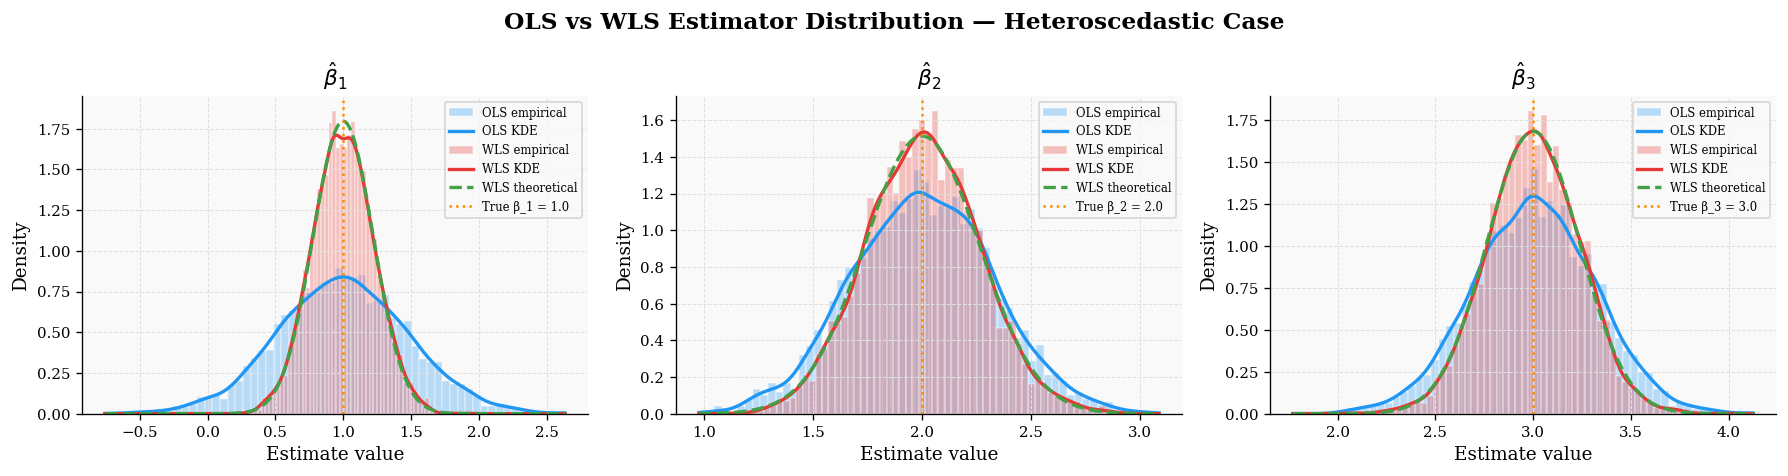

In [40]:
fig, axes = plt.subplots(1, p, figsize=(15, 4))
fig.suptitle("OLS vs WLS Estimator Distribution — Heteroscedastic Case",
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    ols_s = beta_hats_ols_h[:, i]
    wls_s = beta_hats_wls[:, i]
    x_r   = np.linspace(min(ols_s.min(), wls_s.min()),
                        max(ols_s.max(), wls_s.max()), 300)

    ax.hist(ols_s, bins=60, density=True, alpha=0.3,
            color=COLORS['ols'], edgecolor='white', label='OLS empirical')
    ax.plot(x_r, stats.gaussian_kde(ols_s)(x_r),
            color=COLORS['ols'], lw=2, label='OLS KDE')

    ax.hist(wls_s, bins=60, density=True, alpha=0.3,
            color=COLORS['wls'], edgecolor='white', label='WLS empirical')
    ax.plot(x_r, stats.gaussian_kde(wls_s)(x_r),
            color=COLORS['wls'], lw=2, label='WLS KDE')

    theo_std_wls = np.sqrt(theo_cov_wls[i, i])
    ax.plot(x_r, stats.norm.pdf(x_r, beta[i], theo_std_wls),
            color=COLORS['theory'], lw=2, linestyle='--', label='WLS theoretical')
    ax.axvline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle=':', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"$\\hat{{\\beta}}_{i+1}$")
    ax.set_xlabel("Estimate value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("../figures/hetero_distribution.png", bbox_inches='tight')
plt.show()

### 2.5 — Efficiency: OLS vs WLS Variance Comparison

WLS achieves strictly lower variance than OLS under heteroscedastic noise. The efficiency gain (ratio of variances) quantifies how much precision OLS sacrifices by ignoring the noise structure.

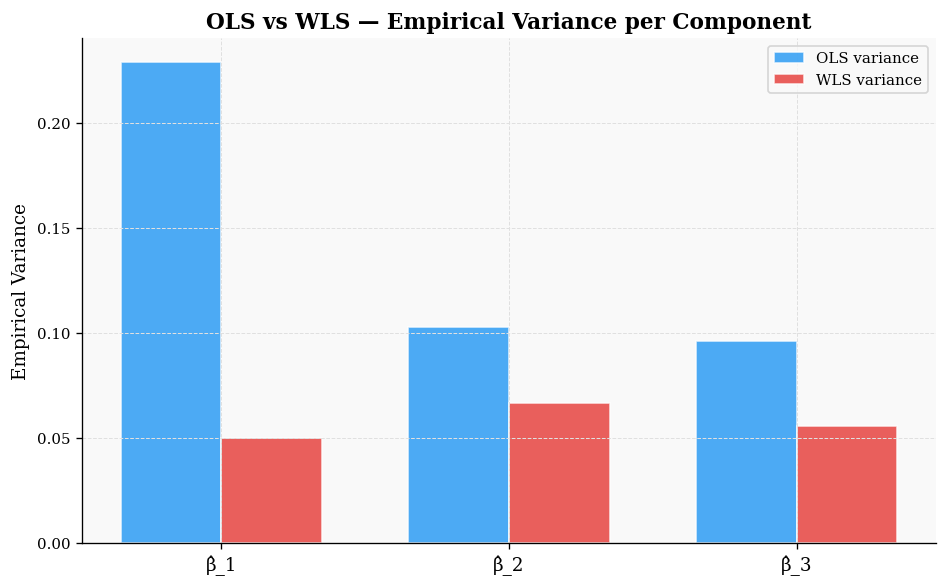

Efficiency gains (OLS var / WLS var):
  β̂_1: OLS=0.2290, WLS=0.0499, gain=4.59×
  β̂_2: OLS=0.1026, WLS=0.0667, gain=1.54×
  β̂_3: OLS=0.0961, WLS=0.0555, gain=1.73×


In [41]:
emp_var_ols = np.diag(emp_cov_ols_h)
emp_var_wls = np.diag(emp_cov_wls)
x      = np.arange(p)
width  = 0.35
labels = [f"β̂_{i+1}" for i in range(p)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, emp_var_ols, width, label='OLS variance',
       color=COLORS['ols'], alpha=0.8, edgecolor='white')
ax.bar(x + width/2, emp_var_wls, width, label='WLS variance',
       color=COLORS['wls'], alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Empirical Variance")
ax.set_title("OLS vs WLS — Empirical Variance per Component", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../figures/hetero_variance_comparison.png", bbox_inches='tight')
plt.show()

efficiency_gain = emp_var_ols / emp_var_wls
print("Efficiency gains (OLS var / WLS var):")
for i in range(p):
    print(f"  β̂_{i+1}: OLS={emp_var_ols[i]:.4f}, WLS={emp_var_wls[i]:.4f}, gain={efficiency_gain[i]:.2f}×")

---

## Part 3 — Inference from the Estimator Distribution

*Confidence Intervals for $\hat{\boldsymbol{\beta}}$ and Prediction Intervals for new observations*

Two types of intervals arise from the estimator distribution:

- **Confidence Interval (CI):** covers the true parameter $\boldsymbol{\beta}$ with probability $1-\alpha$. Quantifies uncertainty about the estimator across repeated experiments. Width $\to 0$ as $n \to \infty$.

- **Prediction Interval (PI):** covers a new observation $y^* = \mathbf{x}^{*\top}\boldsymbol{\beta} + \varepsilon^*$ with probability $1-\alpha$. Accounts for both estimator uncertainty **and** future noise $\varepsilon^*$. Width never vanishes.

### 3.1 — Confidence Intervals for $\hat{\boldsymbol{\beta}}$

Under homoscedastic noise, $\hat{\beta}_j \sim \mathcal{N}\!\left(\beta_j,\;\sigma^2[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}\right)$.

The $(1-\alpha)$ confidence interval for $\beta_j$:

$$\hat{\beta}_j \pm z_{\alpha/2}\cdot\sqrt{\sigma^2[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}}$$

where $z_{\alpha/2}$ is the standard normal quantile (z-interval since $\sigma^2$ is known in simulation; in practice a $t$-interval is used).

In [42]:
alpha    = 0.05
z        = stats.norm.ppf(1 - alpha / 2)
se_ols   = np.sqrt(np.diag(theo_cov_homo))
ci_lower = beta - z * se_ols
ci_upper = beta + z * se_ols

print(f"Confidence level : {int((1-alpha)*100)}%")
print(f"z_{{α/2}}          : {z:.4f}\n")
print(f"{'Component':<12} {'True β':>8} {'SE':>10} {'CI Lower':>12} {'CI Upper':>12}")
print("=" * 58)
for i in range(p):
    print(f"  β_{i+1}         {beta[i]:>8.4f} {se_ols[i]:>10.4f} "
          f"{ci_lower[i]:>12.4f} {ci_upper[i]:>12.4f}")

Confidence level : 95%
z_{α/2}          : 1.9600

Component      True β         SE     CI Lower     CI Upper
  β_1           1.0000     0.1223       0.7603       1.2397
  β_2           2.0000     0.1022       1.7998       2.2002
  β_3           3.0000     0.0916       2.8204       3.1796


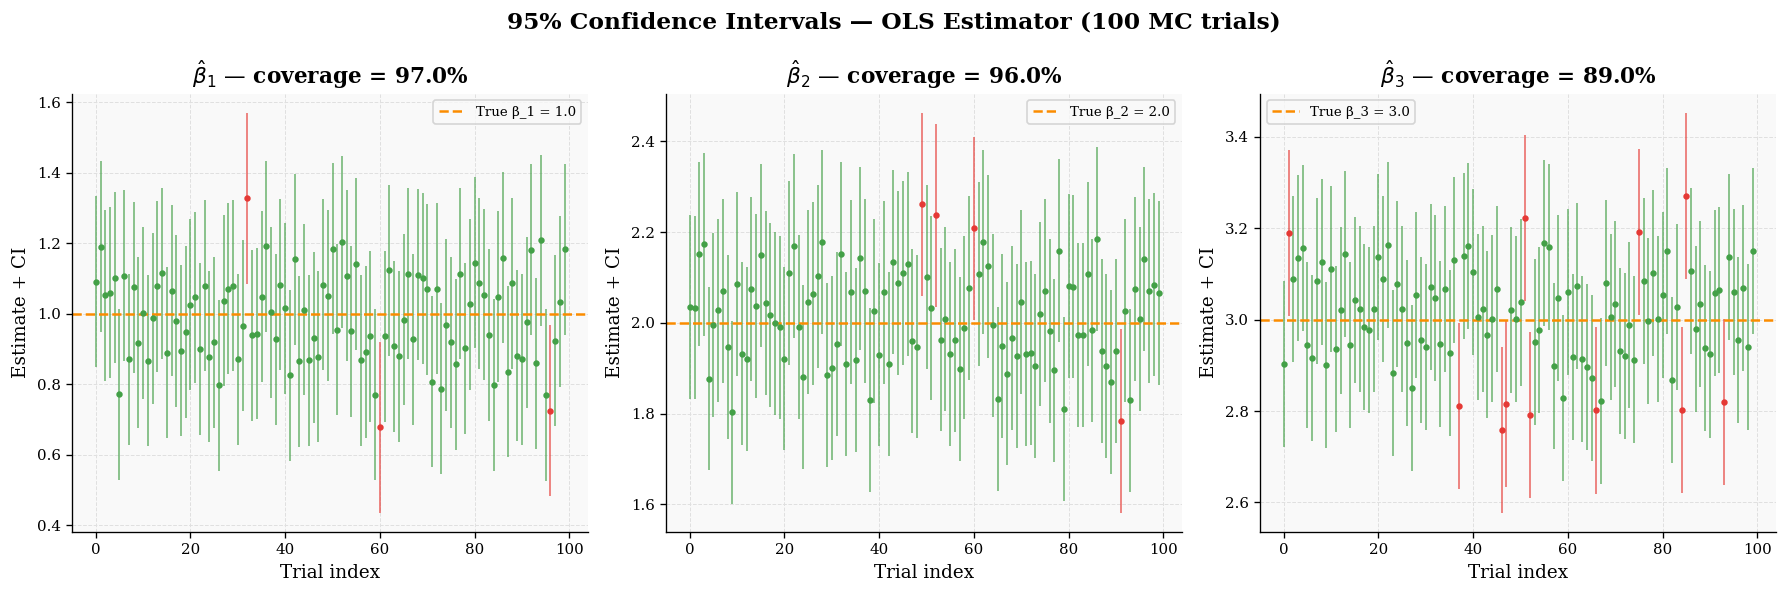

Empirical coverage across all M = 5000 trials:
  β̂_1: 94.72%  (target 95%)
  β̂_2: 95.04%  (target 95%)
  β̂_3: 94.70%  (target 95%)


In [43]:
n_show    = 100
estimates = beta_hats_homo[:n_show, :]

fig, axes = plt.subplots(1, p, figsize=(15, 5))
fig.suptitle("95% Confidence Intervals — OLS Estimator (100 MC trials)",
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    covered = []
    for m in range(n_show):
        b_hat = estimates[m, i]
        lo    = b_hat - z * se_ols[i]
        hi    = b_hat + z * se_ols[i]
        color = COLORS['theory'] if lo <= beta[i] <= hi else COLORS['wls']
        ax.plot([m, m], [lo, hi], color=color, alpha=0.6, lw=1.2)
        ax.scatter(m, b_hat, color=color, s=8, zorder=3)
        covered.append(lo <= beta[i] <= hi)
    ax.axhline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle='--', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"$\\hat{{\\beta}}_{i+1}$ — coverage = {np.mean(covered)*100:.1f}%")
    ax.set_xlabel("Trial index")
    ax.set_ylabel("Estimate + CI")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/ci_plot.png", bbox_inches='tight')
plt.show()

coverage = []
for i in range(p):
    lo = beta_hats_homo[:, i] - z * se_ols[i]
    hi = beta_hats_homo[:, i] + z * se_ols[i]
    coverage.append(np.mean((lo <= beta[i]) & (beta[i] <= hi)))
print("Empirical coverage across all M = 5000 trials:")
for i in range(p):
    print(f"  β̂_{i+1}: {coverage[i]*100:.2f}%  (target 95%)")

### 3.2 — Prediction Intervals for New Observations

For a new input $\mathbf{x}^*$, the predicted response is $\hat{y}^* = \mathbf{x}^{*\top}\hat{\boldsymbol{\beta}}$.

The prediction error $y^* - \hat{y}^* = \mathbf{x}^{*\top}(\boldsymbol{\beta} - \hat{\boldsymbol{\beta}}) + \varepsilon^*$ has two variance sources:

$$\operatorname{Var}(y^* - \hat{y}^*) = \underbrace{\sigma^2\,\mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*}_{\text{estimator uncertainty}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

$$= \sigma^2\!\left(1 + \mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*\right)$$

The $(1-\alpha)$ prediction interval:

$$\hat{y}^* \pm z_{\alpha/2}\cdot\sigma\sqrt{1 + \mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*}$$

As $n \to \infty$, the CI width $\to 0$ but the PI width $\to 2z_{\alpha/2}\sigma$ — future noise is irreducible.

In [44]:
x_star   = X.mean(axis=0)
y_star   = x_star @ beta
beta_hat = beta_hats_homo.mean(axis=0)
y_hat    = x_star @ beta_hat

ci_var = sigma2 * (x_star @ XtX_inv @ x_star)
ci_se  = np.sqrt(ci_var)
ci_lo  = y_hat - z * ci_se
ci_hi  = y_hat + z * ci_se

pi_var = sigma2 * (1 + x_star @ XtX_inv @ x_star)
pi_se  = np.sqrt(pi_var)
pi_lo  = y_hat - z * pi_se
pi_hi  = y_hat + z * pi_se

print(f"New point x*     : {x_star.round(4)}")
print(f"True y*          : {y_star:.4f}")
print(f"Predicted ŷ*     : {y_hat:.4f}\n")
print(f"95% CI : [{ci_lo:.4f}, {ci_hi:.4f}]  width = {ci_hi - ci_lo:.4f}")
print(f"95% PI : [{pi_lo:.4f}, {pi_hi:.4f}]  width = {pi_hi - pi_lo:.4f}")

New point x*     : [ 0.0918 -0.1832  0.0748]
True y*          : -0.0502
Predicted ŷ*     : -0.0505

95% CI : [-0.0929, -0.0080]  width = 0.0850
95% PI : [-2.0109, 1.9100]  width = 3.9208


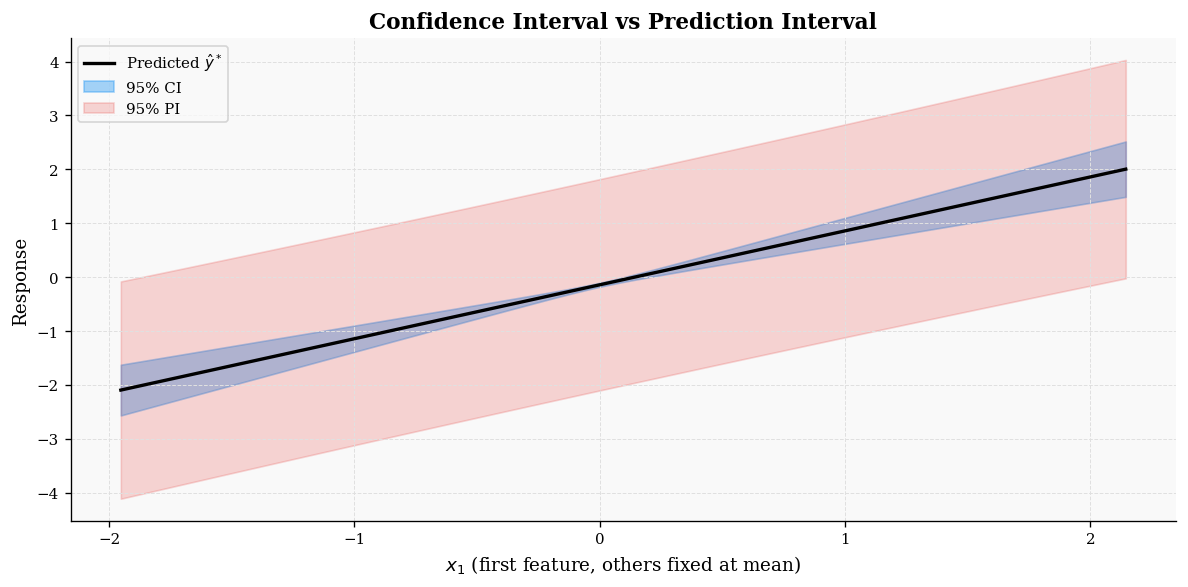

In [45]:
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x_stars  = np.column_stack([
    x1_range,
    np.full(100, X[:, 1].mean()),
    np.full(100, X[:, 2].mean())
])
y_hats  = x_stars @ beta_hat
ci_half = z * np.sqrt(sigma2 * np.array([x @ XtX_inv @ x for x in x_stars]))
pi_half = z * np.sqrt(sigma2 * np.array([1 + x @ XtX_inv @ x for x in x_stars]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x1_range, y_hats, color='black', lw=2, label='Predicted $\\hat{y}^*$')
ax.fill_between(x1_range, y_hats - ci_half, y_hats + ci_half,
                alpha=0.4, color=COLORS['ols'], label='95% CI')
ax.fill_between(x1_range, y_hats - pi_half, y_hats + pi_half,
                alpha=0.2, color=COLORS['wls'], label='95% PI')
ax.set_xlabel("$x_1$ (first feature, others fixed at mean)")
ax.set_ylabel("Response")
ax.set_title("Confidence Interval vs Prediction Interval", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../figures/ci_vs_pi.png", bbox_inches='tight')
plt.show()

### 3.3 — Key Distinction: CI vs PI

| Property | Confidence Interval | Prediction Interval |
|---|---|---|
| **Covers** | True mean response $\mathbf{x}^{*\top}\boldsymbol{\beta}$ | New observation $y^* = \mathbf{x}^{*\top}\boldsymbol{\beta} + \varepsilon^*$ |
| **Variance** | $\sigma^2\,\mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*$ | $\sigma^2\!\left(1 + \mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*\right)$ |
| **As $n \to \infty$** | Width $\to 0$ | Width $\to 2z_{\alpha/2}\sigma > 0$ |
| **Use case** | Estimating the average effect | Forecasting individual outcomes |

The PI is always strictly wider than the CI by the extra $\sigma^2$ term, reflecting irreducible observation noise.

---

## Part 0 — Exploratory Data Analysis

*Advertising Dataset · TV, Radio, Newspaper spend vs Sales*

The **Advertising dataset** (James et al., ISLR) contains **200 observations** across 4 continuous variables:

| Column (exact name) | Description |
|---|---|
| `TV` | Advertising budget allocated to television ($000s) |
| `radio` | Advertising budget allocated to radio ($000s) |
| `newspaper` | Advertising budget allocated to newspapers ($000s) |
| `sales` | Product sales in thousands of units — **response variable** |

> Column names are case-sensitive: `TV` is uppercase; `radio`, `newspaper`, `sales` are lowercase.

The goal: model `sales` as a linear function of the advertising budgets. This dataset exhibits clear linear trends alongside potential **heteroscedasticity**, making it ideal for comparing OLS and WLS.

In [46]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df  = pd.read_csv(url, index_col=0)
print(f"Shape        : {df.shape[0]} observations × {df.shape[1]} variables")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Columns      : {list(df.columns)}\n")
print(df.head(10).to_string())

Shape        : 200 observations × 4 variables
Missing vals : 0
Columns      : ['TV', 'radio', 'newspaper', 'sales']

       TV  radio  newspaper  sales
1   230.1   37.8       69.2   22.1
2    44.5   39.3       45.1   10.4
3    17.2   45.9       69.3    9.3
4   151.5   41.3       58.5   18.5
5   180.8   10.8       58.4   12.9
6     8.7   48.9       75.0    7.2
7    57.5   32.8       23.5   11.8
8   120.2   19.6       11.6   13.2
9     8.6    2.1        1.0    4.8
10  199.8    2.6       21.2   10.6


### Variable Distributions & Correlation

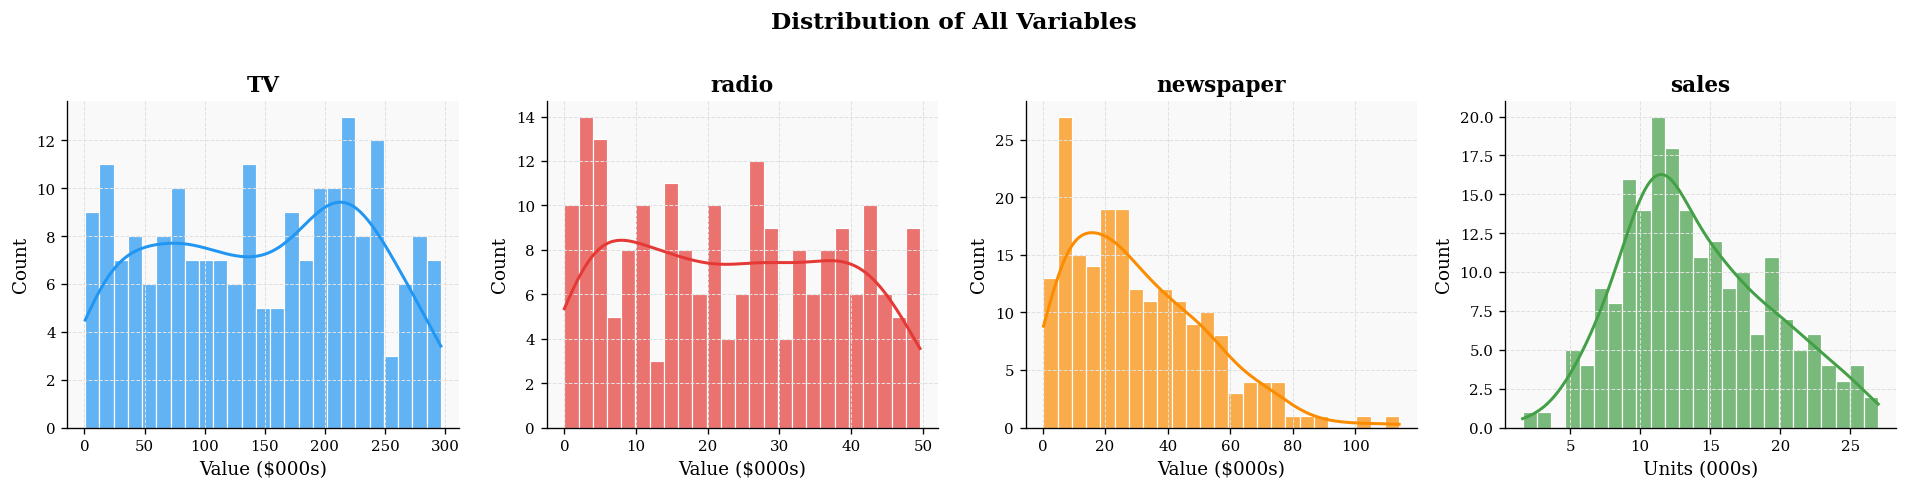

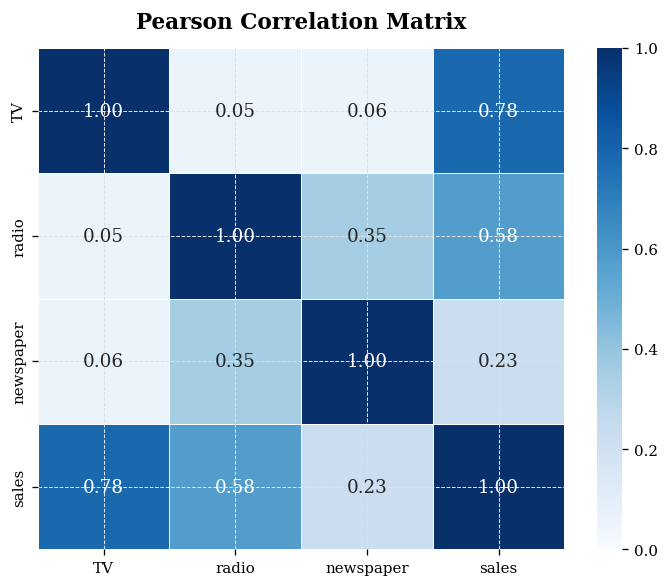

TV-Sales correlation   : 0.782
Radio-Sales correlation: 0.576
News-Sales correlation : 0.228


In [47]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Distribution of All Variables", fontsize=14, fontweight='bold', y=1.01)
for ax, col, color in zip(axes, df.columns,
                          [COLORS['ols'], COLORS['wls'], COLORS['accent'], COLORS['theory']]):
    sns.histplot(df[col], ax=ax, color=color, kde=True, bins=25, alpha=0.7, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("Value ($000s)" if col != "sales" else "Units (000s)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/eda_distributions.png", bbox_inches='tight')
plt.show()

corr = df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0, vmax=1, annot_kws={"size": 11})
ax.set_title("Pearson Correlation Matrix", pad=12)
plt.tight_layout()
plt.savefig("../figures/eda_correlation.png", bbox_inches='tight')
plt.show()

print(f"TV-Sales correlation   : {corr.loc['TV','sales']:.3f}")
print(f"Radio-Sales correlation: {corr.loc['radio','sales']:.3f}")
print(f"News-Sales correlation : {corr.loc['newspaper','sales']:.3f}")

### Feature vs Sales (Marginal Relationships)

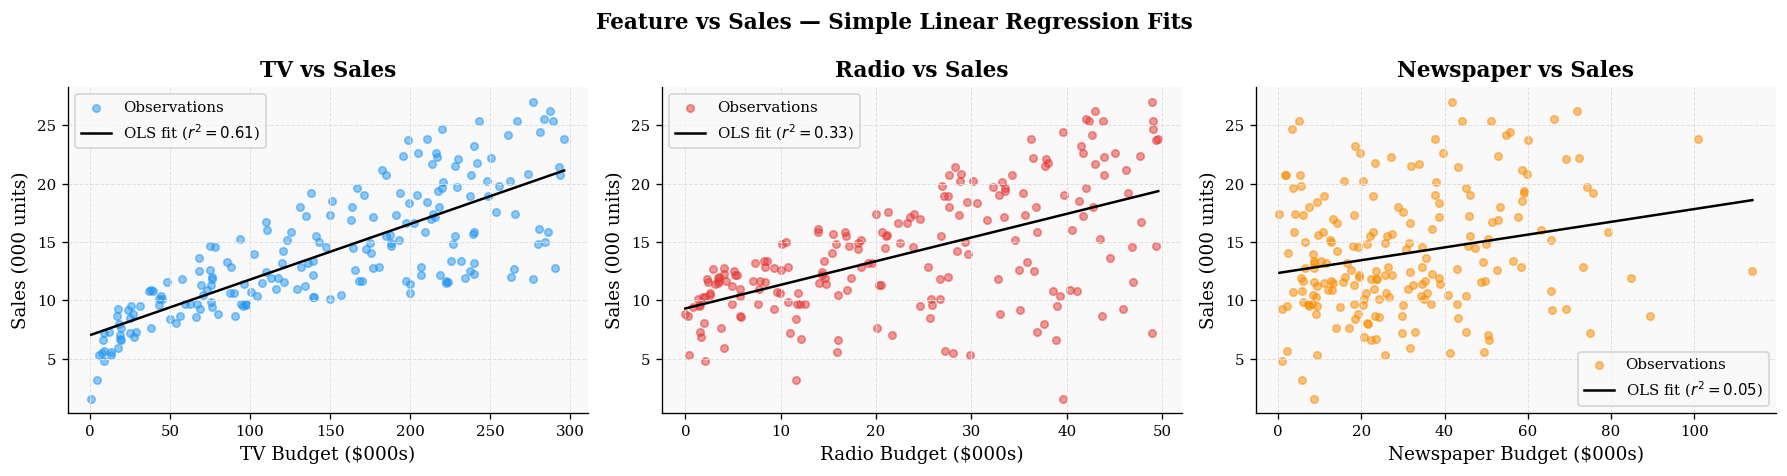

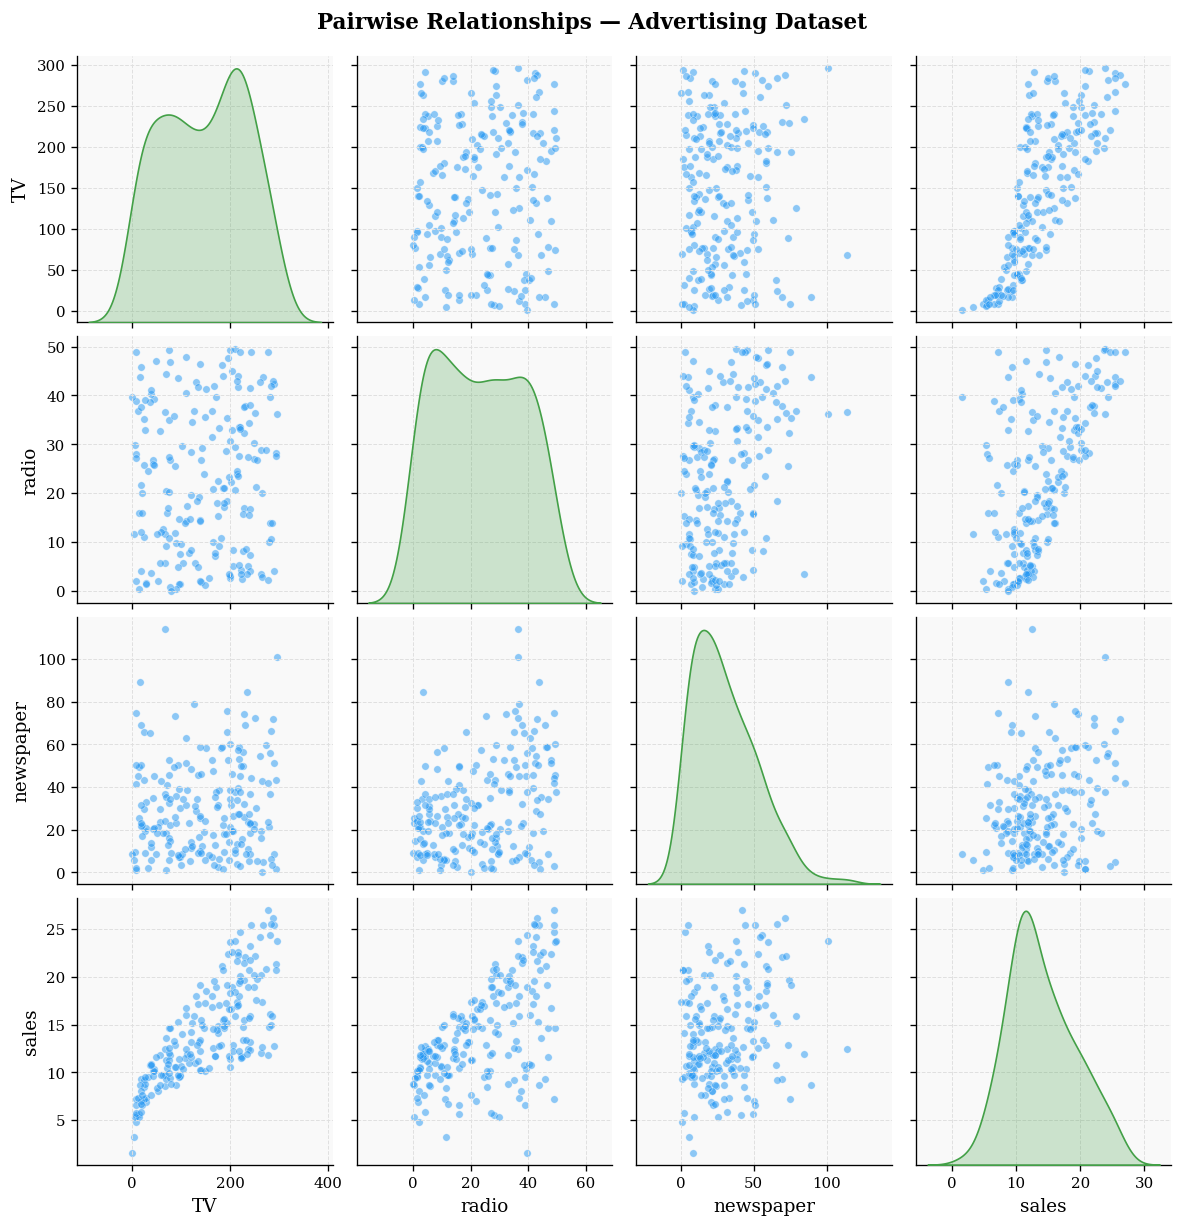

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features      = ['TV', 'radio', 'newspaper']
display_names = ['TV', 'Radio', 'Newspaper']
colors    = [COLORS['ols'], COLORS['wls'], COLORS['accent']]

for ax, feat, dname, col in zip(axes, features, display_names, colors):
    ax.scatter(df[feat], df['sales'], alpha=0.5, color=col, s=20, label='Observations')
    m, b_lr, r, p_lr, _ = stats.linregress(df[feat], df['sales'])
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b_lr, color='black', lw=1.5,
            label=f'OLS fit ($r^2={r**2:.2f}$)')
    ax.set_xlabel(f"{dname} Budget (\$000s)")
    ax.set_ylabel("Sales (000 units)")
    ax.set_title(f"{dname} vs Sales")
    ax.legend()

fig.suptitle("Feature vs Sales — Simple Linear Regression Fits",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/eda_scatter.png", bbox_inches='tight')
plt.show()

g = sns.pairplot(df, diag_kind='kde',
                 plot_kws={'alpha':0.5, 'color': COLORS['ols'], 's': 20},
                 diag_kws={'color': COLORS['theory'], 'fill': True})
g.figure.suptitle("Pairwise Relationships — Advertising Dataset",
                  y=1.02, fontsize=13, fontweight='bold')
plt.savefig("../figures/eda_pairplot.png", bbox_inches='tight')
plt.show()

### Descriptive Statistics

In [49]:
print(df.describe().T.round(3).to_string())

           count     mean     std  min     25%     50%      75%    max
TV         200.0  147.042  85.854  0.7  74.375  149.75  218.825  296.4
radio      200.0   23.264  14.847  0.0   9.975   22.90   36.525   49.6
newspaper  200.0   30.554  21.779  0.3  12.750   25.75   45.100  114.0
sales      200.0   14.022   5.217  1.6  10.375   12.90   17.400   27.0


---

## Part 4 — Real Data Application: Advertising Dataset

*OLS fit · Residual analysis · Heteroscedasticity detection · WLS correction*

### 4.1 — Model Setup

We model Sales as a linear function of TV, Radio, and Newspaper budgets:

$$\text{Sales}_i = \beta_0 + \beta_1\cdot\text{TV}_i + \beta_2\cdot\text{Radio}_i + \beta_3\cdot\text{Newspaper}_i + \varepsilon_i$$

The design matrix $\mathbf{X}$ includes an intercept column, giving $p = 4$ parameters. We first assume $\varepsilon \sim \mathcal{N}(0, \sigma^2\mathbf{I})$ and fit OLS, then investigate whether this homoscedastic assumption holds.

In [50]:
y_real = df['sales'].values
X_real = np.column_stack([
    np.ones(len(df)),
    df['TV'].values,
    df['radio'].values,
    df['newspaper'].values
])
feature_names = ['Intercept', 'TV', 'Radio', 'Newspaper']
print(f"Design matrix shape : {X_real.shape}")
print(f"Response shape      : {y_real.shape}")
print(f"Features            : {feature_names}")

Design matrix shape : (200, 4)
Response shape      : (200,)
Features            : ['Intercept', 'TV', 'Radio', 'Newspaper']


### 4.2 — OLS Fit

$$\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Standard errors use the unbiased estimator $\hat{\sigma}^2 = \|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2 / (n-p)$, giving $t$-statistics and $p$-values for each coefficient.

In [51]:
beta_ols_real = ols(X_real, y_real)
residuals     = y_real - X_real @ beta_ols_real
n_real        = len(y_real)
p_real        = X_real.shape[1]
sigma2_est    = np.sum(residuals**2) / (n_real - p_real)
XtX_inv_real  = np.linalg.inv(X_real.T @ X_real)
se_real       = np.sqrt(sigma2_est * np.diag(XtX_inv_real))
t_stats       = beta_ols_real / se_real
p_values      = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_real - p_real))

print(f"σ² estimate : {sigma2_est:.4f}")
print(f"R²          : {1 - np.sum(residuals**2)/np.sum((y_real - y_real.mean())**2):.4f}\n")
print(f"{'Feature':<12} {'β̂':>10} {'SE':>10} {'t-stat':>10} {'p-value':>12}")
print("=" * 58)
for i, name in enumerate(feature_names):
    print(f"  {name:<10} {beta_ols_real[i]:>10.4f} {se_real[i]:>10.4f} "
          f"{t_stats[i]:>10.4f} {p_values[i]:>12.4f}")

σ² estimate : 2.8409
R²          : 0.8972

Feature              β̂         SE     t-stat      p-value
  Intercept      2.9389     0.3119     9.4223       0.0000
  TV             0.0458     0.0014    32.8086       0.0000
  Radio          0.1885     0.0086    21.8935       0.0000
  Newspaper     -0.0010     0.0059    -0.1767       0.8599


### 4.3 — Residual Analysis

Three diagnostic plots:

1. **Residuals vs Fitted** — should show no pattern under homoscedasticity
2. **Normal Q-Q** — standardised residuals should lie on the diagonal
3. **Residuals vs TV** — checks if variance depends on the dominant predictor

Residual mean  : -0.000000  (should be ≈ 0)
Residual std   : 1.6686


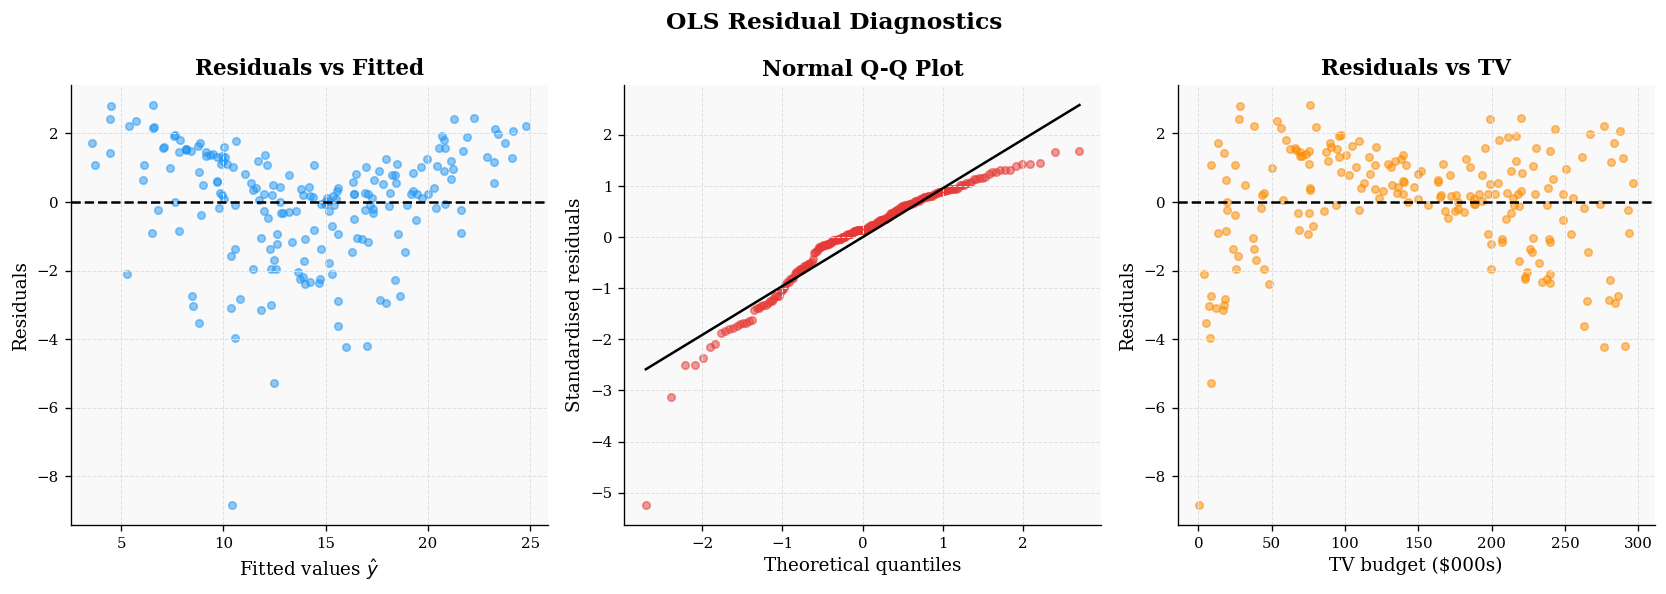

In [52]:
y_fitted      = X_real @ beta_ols_real
residuals_std = residuals / np.sqrt(sigma2_est)

print(f"Residual mean  : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"Residual std   : {residuals.std():.4f}")

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])
ax1.scatter(y_fitted, residuals, alpha=0.5, color=COLORS['ols'], s=20)
ax1.axhline(0, color='black', lw=1.5, linestyle='--')
ax1.set_xlabel("Fitted values $\\hat{y}$")
ax1.set_ylabel("Residuals")
ax1.set_title("Residuals vs Fitted", fontweight='bold')

ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuals_std, dist="norm")
ax2.scatter(osm, osr, alpha=0.5, color=COLORS['wls'], s=20)
ax2.plot(osm, slope*np.array(osm) + intercept, color='black', lw=1.5)
ax2.set_xlabel("Theoretical quantiles")
ax2.set_ylabel("Standardised residuals")
ax2.set_title("Normal Q-Q Plot", fontweight='bold')

ax3 = fig.add_subplot(gs[2])
ax3.scatter(df['TV'], residuals, alpha=0.5, color=COLORS['accent'], s=20)
ax3.axhline(0, color='black', lw=1.5, linestyle='--')
ax3.set_xlabel("TV budget (\$000s)")
ax3.set_ylabel("Residuals")
ax3.set_title("Residuals vs TV", fontweight='bold')

fig.suptitle("OLS Residual Diagnostics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/residual_diagnostics.png", bbox_inches='tight')
plt.show()

### 4.4 — Heteroscedasticity Detection: White's Test

**White's Test** formally tests for heteroscedasticity:

- $H_0$: homoscedasticity — $\operatorname{Var}(\varepsilon_i) = \sigma^2$ for all $i$
- $H_1$: heteroscedasticity — $\operatorname{Var}(\varepsilon_i)$ depends on $\mathbf{X}$

**Procedure:**
1. Compute OLS residuals $\hat{\boldsymbol{\varepsilon}}$
2. Regress $\hat{\varepsilon}_i^2$ on $\mathbf{X}$, $\mathbf{X}^2$, and all cross-products (auxiliary regression)
3. Test statistic: $\mathrm{LM} = n \cdot R^2_{\mathrm{aux}} \sim \chi^2(k)$ under $H_0$

White's test is preferred over Breusch-Pagan here because it captures **nonlinear** heteroscedasticity — BP only tests for a linear dependence of $\operatorname{Var}(\varepsilon_i)$ on $\mathbf{X}$.

White's Test for Heteroscedasticity
  LM statistic       : 67.5352
  LM p-value         : 0.000000
  F statistic        : 10.7632
  F p-value          : 0.000000

  REJECT H₀ — Heteroscedasticity detected ✓


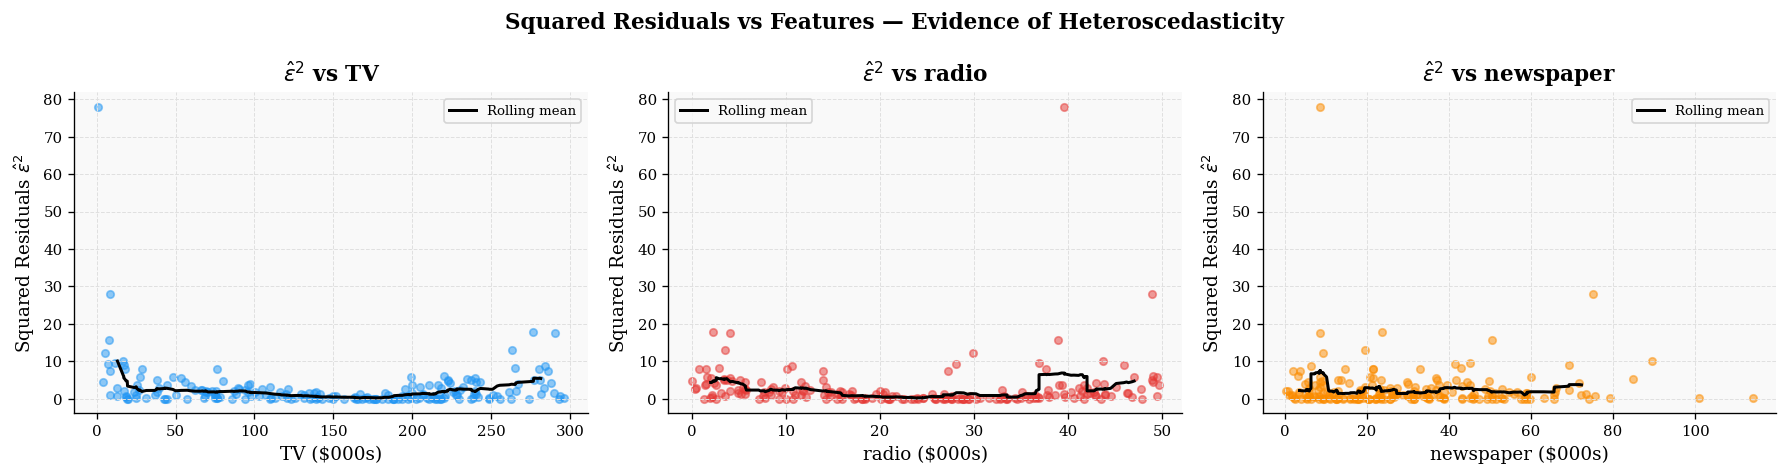

In [53]:
from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm

LM, p_val, F_stat, p_val_F = het_white(residuals, X_real)
print("White's Test for Heteroscedasticity")
print("=" * 40)
print(f"  LM statistic       : {LM:.4f}")
print(f"  LM p-value         : {p_val:.6f}")
print(f"  F statistic        : {F_stat:.4f}")
print(f"  F p-value          : {p_val_F:.6f}")
print(f"\n  {'REJECT H₀ — Heteroscedasticity detected ✓' if p_val < 0.05 else 'Fail to reject H₀'}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features      = ['TV', 'radio', 'newspaper']
display_names = ['TV', 'Radio', 'Newspaper']
colors    = [COLORS['ols'], COLORS['wls'], COLORS['accent']]

for ax, feat, col in zip(axes, features, colors):
    ax.scatter(df[feat], residuals**2, alpha=0.5, color=col, s=20)
    sort_idx = np.argsort(df[feat].values)
    x_s      = df[feat].values[sort_idx]
    y_s      = (residuals**2)[sort_idx]
    smooth   = pd.Series(y_s).rolling(20, center=True).mean()
    ax.plot(x_s, smooth, color='black', lw=1.8, label='Rolling mean')
    ax.set_xlabel(f"{feat} (\$000s)")
    ax.set_ylabel(r"Squared Residuals $\hat{\varepsilon}^2$")
    ax.set_title(f"$\\hat{{\\varepsilon}}^2$ vs {feat}", fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle("Squared Residuals vs Features — Evidence of Heteroscedasticity",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/hetero_evidence.png", bbox_inches='tight')
plt.show()

### 4.5 — WLS Fit using Estimated Weights

Since $\boldsymbol{\Sigma}$ is unknown in practice, we use the **Feasible WLS (FWLS)** two-step procedure:

1. Fit OLS and obtain residuals $\hat{\boldsymbol{\varepsilon}}$
2. Estimate observation-level variances: $\hat{\sigma}_i^2 \approx |\hat{\varepsilon}_i|$
3. Set weights $w_i = 1/\hat{\sigma}_i^2$ and construct $\hat{\boldsymbol{\Sigma}}^{-1} = \operatorname{diag}(w_1,\ldots,w_n)$
4. Fit WLS: $\hat{\boldsymbol{\beta}}_{\mathrm{WLS}} = (\mathbf{X}^\top\hat{\boldsymbol{\Sigma}}^{-1}\mathbf{X})^{-1}\mathbf{X}^\top\hat{\boldsymbol{\Sigma}}^{-1}\mathbf{y}$

Feature          OLS β̂     WLS β̂     OLS SE     WLS SE
  Intercept      2.9389     2.9544     0.3119     0.1211
  TV             0.0458     0.0457     0.0014     0.0005
  Radio          0.1885     0.1909     0.0086     0.0042
  Newspaper     -0.0010    -0.0015     0.0059     0.0021


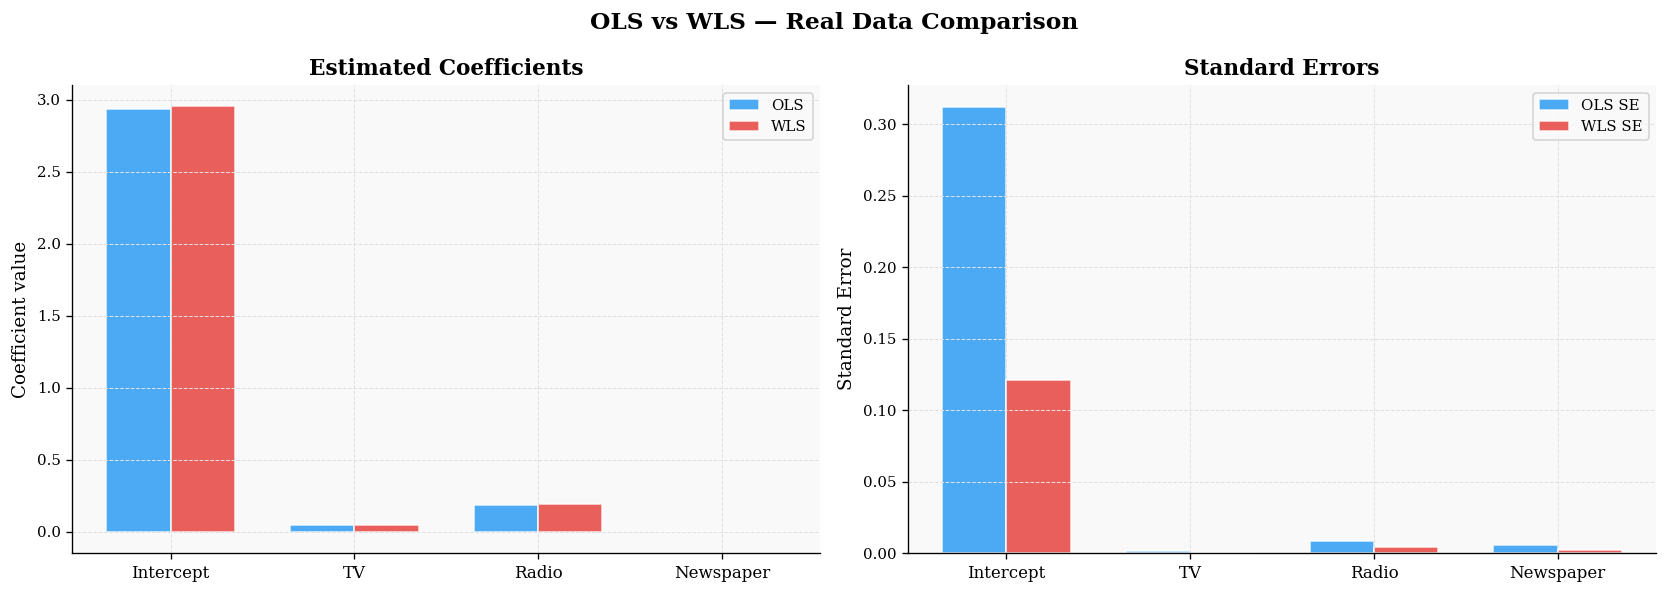

In [54]:
weights        = 1.0 / (np.abs(residuals) + 1e-6)
Sigma_inv_real = np.diag(weights)
beta_wls_real  = wls(X_real, y_real, Sigma_inv_real)

resid_wls  = y_real - X_real @ beta_wls_real
XtWX_inv   = np.linalg.inv(X_real.T @ Sigma_inv_real @ X_real)
sigma2_wls = np.sum(weights * resid_wls**2) / (n_real - p_real)
se_wls     = np.sqrt(sigma2_wls * np.diag(XtWX_inv))

print(f"{'Feature':<12} {'OLS β̂':>10} {'WLS β̂':>10} {'OLS SE':>10} {'WLS SE':>10}")
print("=" * 58)
for i, name in enumerate(feature_names):
    print(f"  {name:<10} {beta_ols_real[i]:>10.4f} {beta_wls_real[i]:>10.4f} "
          f"{se_real[i]:>10.4f} {se_wls[i]:>10.4f}")

x      = np.arange(p_real)
width  = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OLS vs WLS — Real Data Comparison", fontsize=14, fontweight='bold')

axes[0].bar(x - width/2, beta_ols_real, width, label='OLS',
            color=COLORS['ols'], alpha=0.8, edgecolor='white')
axes[0].bar(x + width/2, beta_wls_real, width, label='WLS',
            color=COLORS['wls'], alpha=0.8, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_names, fontsize=10)
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Estimated Coefficients", fontweight='bold')
axes[0].legend()

axes[1].bar(x - width/2, se_real, width, label='OLS SE',
            color=COLORS['ols'], alpha=0.8, edgecolor='white')
axes[1].bar(x + width/2, se_wls, width, label='WLS SE',
            color=COLORS['wls'], alpha=0.8, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names, fontsize=10)
axes[1].set_ylabel("Standard Error")
axes[1].set_title("Standard Errors", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/ols_vs_wls_real.png", bbox_inches='tight')
plt.show()

---

## Bonus — Fisher Information, CRLB, and Sufficient Statistics

*Theoretical optimality of OLS · Data compression via sufficiency*

### Fisher Information Matrix and the Cramér-Rao Lower Bound

For $\mathbf{y} \sim \mathcal{N}(\mathbf{X}\boldsymbol{\beta}, \sigma^2\mathbf{I})$, the log-likelihood is:

$$\ell(\boldsymbol{\beta}) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2}{2\sigma^2}$$

**Score function:**

$$\frac{\partial\ell}{\partial\boldsymbol{\beta}} = \frac{1}{\sigma^2}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

**Fisher Information Matrix:**

$$\mathcal{I}(\boldsymbol{\beta}) = -\mathbb{E}\!\left[\frac{\partial^2\ell}{\partial\boldsymbol{\beta}\,\partial\boldsymbol{\beta}^\top}\right] = \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{X}$$

**Cramér-Rao Lower Bound:** For any unbiased estimator $\tilde{\boldsymbol{\beta}}$:

$$\operatorname{Var}(\tilde{\boldsymbol{\beta}}) \;\geq\; \mathcal{I}(\boldsymbol{\beta})^{-1} = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$$

**OLS achieves the CRLB:**

$$\operatorname{Var}(\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}) = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1} = \mathcal{I}(\boldsymbol{\beta})^{-1}$$

Therefore $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}$ is the **UMVUE** (Uniformly Minimum Variance Unbiased Estimator) under homoscedastic Gaussian noise.

In [55]:
crlb_diag    = np.diag(sigma2 * XtX_inv)
emp_var_homo = np.diag(np.cov(beta_hats_homo.T))

print("Fisher Information  I(β) = XᵀX / σ²")
print("CRLB                     = I(β)⁻¹ = σ²(XᵀX)⁻¹")
print("=" * 60)
print(f"  {'Component':<12} {'CRLB':>12} {'Emp. Var':>12} {'Ratio':>8}")
print("-" * 60)
for i in range(p):
    ratio = emp_var_homo[i] / crlb_diag[i]
    print(f"  beta_{i+1}       {crlb_diag[i]:>12.6f} {emp_var_homo[i]:>12.6f} {ratio:>8.4f}")
print("\nRatio ≈ 1.0 confirms OLS achieves the CRLB — it is efficient.")

Fisher Information  I(β) = XᵀX / σ²
CRLB                     = I(β)⁻¹ = σ²(XᵀX)⁻¹
  Component            CRLB     Emp. Var    Ratio
------------------------------------------------------------
  beta_1           0.014958     0.014874   0.9944
  beta_2           0.010437     0.010561   1.0120
  beta_3           0.008393     0.008583   1.0226

Ratio ≈ 1.0 confirms OLS achieves the CRLB — it is efficient.


### Sufficient Statistics via the Neyman-Fisher Factorization Theorem

**Definition:** $T(\mathbf{y})$ is sufficient for $\theta$ iff $p(\mathbf{y}\mid\theta) = g(T(\mathbf{y}), \theta)\cdot h(\mathbf{y})$.

**For the Gaussian linear model:**

$$p(\mathbf{y}\mid\boldsymbol{\beta}) \propto \exp\!\left(-\frac{\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2}{2\sigma^2}\right) = \exp\!\left(-\frac{\|\mathbf{y}\|^2}{2\sigma^2}\right)\exp\!\left(\frac{\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y}}{\sigma^2}\right)\exp\!\left(-\frac{\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta}}{2\sigma^2}\right)$$

By the Factorization Theorem:

- $T_1(\mathbf{y}) = \mathbf{X}^\top\mathbf{y}$ is sufficient for $\boldsymbol{\beta}$ — a $p$-dimensional vector
- $T_2(\mathbf{y}) = \|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2$ is sufficient for $\sigma^2$

**Data compression:** $\mathbf{y}$ has $n$ values; $\mathbf{X}^\top\mathbf{y}$ has only $p$ values. Yet $\mathbf{X}^\top\mathbf{y}$ captures *all* information about $\boldsymbol{\beta}$ in $\mathbf{y}$ — the remaining $n-p$ degrees of freedom carry only noise.

**Connection to UMVUE:** Since $\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}T_1(\mathbf{y})$ is a function of the sufficient statistic, the Rao-Blackwell theorem guarantees it is UMVUE.

In [56]:
print("Sufficient statistic T₁(y) = Xᵀy")
print(f"Dimension of y      : {n}  (original observations)")
print(f"Dimension of Xᵀy    : {p}  (sufficient statistic for β)")
print()

np.random.seed(0)
eps_demo             = np.random.normal(0, np.sqrt(sigma2), n)
y_demo               = X @ beta + eps_demo
XtY_demo             = X.T @ y_demo
beta_from_sufficient = XtX_inv @ XtY_demo

print(f"β̂ from full y     : {ols(X, y_demo).round(6)}")
print(f"β̂ from Xᵀy only   : {beta_from_sufficient.round(6)}")
print(f"True β             : {beta}")
print()
print("Both are identical — Xᵀy is sufficient; no information about β is lost.")

Sufficient statistic T₁(y) = Xᵀy
Dimension of y      : 100  (original observations)
Dimension of Xᵀy    : 3  (sufficient statistic for β)

β̂ from full y     : [1.059058 2.013729 2.941469]
β̂ from Xᵀy only   : [1.059058 2.013729 2.941469]
True β             : [1. 2. 3.]

Both are identical — Xᵀy is sufficient; no information about β is lost.
